In [2]:
# ============================================================
# BOOTSTRAP CELL — standalone notebook setup
# ============================================================

from __future__ import annotations

import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

# ------------------------------------------------------------
# Find project root robustly
# ------------------------------------------------------------


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()

    current = start

    while current != current.parent:
        if (current / "data").exists() and (current / "results").exists():
            return current
        current = current.parent

    raise RuntimeError(
        "Could not find project root. "
        "Run this notebook from inside the drug-discovery-lohi repository."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


# ------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------

TASK = "hi"
RANDOM_STATE = 42
N_BITS = 1024
RADIUS = 2

DATASETS_MAIN = ["drd2", "hiv", "sol"]

DATA_DIR = PROJECT_ROOT / "data" / TASK
OUT_DIR = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_ROOT.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)
print("FIG_ROOT:", FIG_ROOT)
print("N_BITS:", N_BITS)

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"


# ------------------------------------------------------------
# ECFP4 computation used by the collision analysis
# ------------------------------------------------------------


def compute_ecfp4_bits(
    smiles_list: list[str],
    n_bits: int = 1024,
    radius: int = 2,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute binary ECFP4/Morgan fingerprints.

    Returns:
        X          : binary fingerprint matrix, shape (n_valid_or_raw, n_bits)
        valid_mask : boolean mask over input SMILES
    """
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits,
    )

    fps = []
    valid_mask = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(str(smi))

        if mol is None:
            valid_mask.append(False)
            fps.append(np.zeros(n_bits, dtype=np.uint8))
            continue

        fp = generator.GetFingerprint(mol)

        arr = np.zeros((n_bits,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, arr)

        fps.append(arr)
        valid_mask.append(True)

    X = np.vstack(fps).astype(np.uint8)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    return X, valid_mask


# ------------------------------------------------------------
# Sanity check: List A must already exist and be 1024-bit
# ------------------------------------------------------------

listA_candidates = [
    OUT_DIR / "cross_dataset_listA_activity_feature_importance.csv",
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / TASK
    / "cross_dataset"
    / "cross_dataset_feature_importance_all_tree.csv",
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / TASK
    / "cross_dataset"
    / "cross_dataset_feature_importance_all.csv",
]

existing_listA = [p for p in listA_candidates if p.exists()]

if not existing_listA:
    raise FileNotFoundError(
        "No List A file found. Tried:\n" + "\n".join(str(p) for p in listA_candidates)
    )

print("List A candidate found:", existing_listA[0])

tmp_listA = pd.read_csv(existing_listA[0], low_memory=False)

assert "feature_idx" in tmp_listA.columns, "List A has no feature_idx column."

max_idx = int(pd.to_numeric(tmp_listA["feature_idx"], errors="coerce").max())

print("List A max feature_idx:", max_idx)

assert max_idx < N_BITS, (
    f"List A max feature_idx={max_idx}, but N_BITS={N_BITS}. "
    "This notebook expects 1024-bit ECFP4 artifacts."
)

print("\nOK: standalone bootstrap completed.")

PROJECT_ROOT: /Users/francescocapria/Desktop/drug-discovery-lohi
DATA_DIR: /Users/francescocapria/Desktop/drug-discovery-lohi/data/hi
OUT_DIR: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi
FIG_ROOT: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures
N_BITS: 1024
List A candidate found: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_activity_feature_importance.csv
List A max feature_idx: 1023

OK: standalone bootstrap completed.


PROJECT_ROOT: /Users/francescocapria/Desktop/drug-discovery-lohi
DATA_DIR: /Users/francescocapria/Desktop/drug-discovery-lohi/data/hi
OUT_DIR: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi
N_BITS: 1024
Loading List A from: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_activity_feature_importance.csv

Prepared List A
shape: (55296, 33)
datasets: ['drd2', 'hiv', 'sol']
models: ['DT', 'LR', 'SVM']
protocols: ['ood', 'random']
folds: [np.int64(1), np.int64(2), np.int64(3)]
max feature_idx: 1023

Saved selected feature sets:
/Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_activity_selected_feature_sets.csv
shape: (216, 9)

Saved feature overlap pairwise:
/Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_activity_feature_set_overlap_pairwise.csv
shape: (216, 16)

Saved 

,dataset,model,activity_protocol,feature_set_name,mean_n_features,mean_jaccard_overlap,min_jaccard_overlap,max_jaccard_overlap,mean_overlap_max_denominator,min_overlap_max_denominator,max_overlap_max_denominator,mean_n_intersection,mean_n_union
0,drd2,DT,ood,mass95,27.666667,0.013853,0.000000,0.031250,0.017041,0.000000,0.037037,0.666667,68.666667
1,drd2,DT,ood,positive,31.000000,0.019730,0.000000,0.040323,0.027521,0.000000,0.061728,2.000000,88.000000
2,drd2,DT,ood,top100,31.000000,0.019730,0.000000,0.040323,0.027521,0.000000,0.061728,2.000000,88.000000
4,drd2,DT,random,mass95,61.666667,0.060068,0.033058,0.111111,0.104274,0.061538,0.184615,6.666667,113.333333
5,drd2,DT,random,positive,75.333333,0.073593,0.047945,0.123188,0.131111,0.087500,0.212500,10.333333,141.666667
6,drd2,DT,random,top100,75.333333,0.073593,0.047945,0.123188,0.131111,0.087500,0.212500,10.333333,141.666667
8,drd2,LR,ood,mass95,435.000000,0.141899,0.033069,0.313776,0.146313,0.033113,0.325828,97.666667,606.333333
9,drd2,LR,ood,positive,593.333333,0.161754,0.033268,0.370841,0.161968,0.033268,0.370841,148.000000,808.666667
10,drd2,LR,ood,top100,100.000000,0.148681,0.107438,0.183432,0.206667,0.130000,0.310000,20.666667,135.333333
12,drd2,LR,random,mass95,748.666667,0.598723,0.585209,0.610097,0.742311,0.730924,0.755319,557.000000,930.333333



Collision analysis: DRD2
drd2 | F1 | n=1191 | X=(1191, 1024) | label_col=value | class_counts={0: np.int64(416), 1: np.int64(775)}
drd2 | F2 | n=1194 | X=(1194, 1024) | label_col=value | class_counts={0: np.int64(285), 1: np.int64(909)}
drd2 | F3 | n=1190 | X=(1190, 1024) | label_col=value | class_counts={0: np.int64(455), 1: np.int64(735)}
drd2 | DT | ood | fold=1 | top50 | bits=6
drd2 | DT | ood | fold=1 | top100 | bits=6
drd2 | DT | ood | fold=1 | mass95 | bits=6
drd2 | DT | ood | fold=1 | positive | bits=6
drd2 | DT | ood | fold=2 | top50 | bits=50
drd2 | DT | ood | fold=2 | top100 | bits=81
drd2 | DT | ood | fold=2 | mass95 | bits=71
drd2 | DT | ood | fold=2 | positive | bits=81
drd2 | DT | ood | fold=3 | top50 | bits=48
drd2 | DT | ood | fold=3 | top100 | bits=48
drd2 | DT | ood | fold=3 | mass95 | bits=27
drd2 | DT | ood | fold=3 | positive | bits=48
drd2 | DT | random | fold=1 | top50 | bits=50
drd2 | DT | random | fold=1 | top100 | bits=73
drd2 | DT | random | fold=1 | mass95

[00:54:54] Explicit valence for atom # 4 Al, 9, is greater than permitted
[00:54:54] Explicit valence for atom # 16 Al, 9, is greater than permitted


hiv | F1: dropping 1 invalid SMILES
hiv | F1 | n=7847 | X=(7847, 1024) | label_col=value | class_counts={0: np.int64(7683), 1: np.int64(164)}


[00:54:55] Explicit valence for atom # 5 B, 5, is greater than permitted
[00:54:55] WARNING: not removing hydrogen atom without neighbors
[00:54:55] WARNING: not removing hydrogen atom without neighbors
[00:54:55] Explicit valence for atom # 3 Al, 6, is greater than permitted
[00:54:56] Explicit valence for atom # 12 Al, 7, is greater than permitted
[00:54:56] Explicit valence for atom # 13 Al, 7, is greater than permitted
[00:54:56] Explicit valence for atom # 6 Ge, 5, is greater than permitted


hiv | F2: dropping 2 invalid SMILES
hiv | F2 | n=7846 | X=(7846, 1024) | label_col=value | class_counts={0: np.int64(7411), 1: np.int64(435)}
hiv | F3: dropping 4 invalid SMILES
hiv | F3 | n=7843 | X=(7843, 1024) | label_col=value | class_counts={0: np.int64(7503), 1: np.int64(340)}
hiv | DT | ood | fold=1 | top50 | bits=26
hiv | DT | ood | fold=1 | top100 | bits=26
hiv | DT | ood | fold=1 | mass95 | bits=23
hiv | DT | ood | fold=1 | positive | bits=26
hiv | DT | ood | fold=2 | top50 | bits=50
hiv | DT | ood | fold=2 | top100 | bits=100
hiv | DT | ood | fold=2 | mass95 | bits=92
hiv | DT | ood | fold=2 | positive | bits=106
hiv | DT | ood | fold=3 | top50 | bits=50
hiv | DT | ood | fold=3 | top100 | bits=100
hiv | DT | ood | fold=3 | mass95 | bits=157
hiv | DT | ood | fold=3 | positive | bits=316
hiv | DT | random | fold=1 | top50 | bits=26
hiv | DT | random | fold=1 | top100 | bits=26
hiv | DT | random | fold=1 | mass95 | bits=23
hiv | DT | random | fold=1 | positive | bits=26
hiv | D

,dataset,model,activity_protocol,context,mean_n_bits_selected,mean_nearest_opposite_sim,q95_nearest_opposite_sim,exact_collision_pct,near_collision_095_pct,distinguishable_095_pct,query_zero_vector_rate
6,drd2,DT,ood,test_to_train_cross,45.000000,0.743670,0.848485,32.800815,32.800815,67.199185,0.011765
7,drd2,DT,ood,test_within,45.000000,0.829965,1.000000,40.656377,40.656377,59.343623,0.011765
8,drd2,DT,ood,train_within,45.000000,0.843356,1.000000,45.700782,45.700782,54.299218,0.014116
18,drd2,DT,random,test_to_train_cross,76.000000,0.589319,0.774603,1.176424,1.176424,98.823576,0.000000
19,drd2,DT,random,test_within,76.000000,0.753397,1.000000,19.899185,19.955019,80.044981,0.000000
20,drd2,DT,random,train_within,76.000000,0.749560,1.000000,13.479169,13.563167,86.436833,0.000140
30,drd2,LR,ood,test_to_train_cross,78.000000,0.562954,0.720058,0.699622,0.699622,99.300378,0.000000
31,drd2,LR,ood,test_within,78.000000,0.749097,1.000000,16.114029,16.114029,83.885971,0.000000
32,drd2,LR,ood,train_within,78.000000,0.745493,1.000000,15.426342,15.733820,84.266180,0.000000
42,drd2,LR,random,test_to_train_cross,100.000000,0.528586,0.731481,0.614722,0.614722,99.385278,0.000000


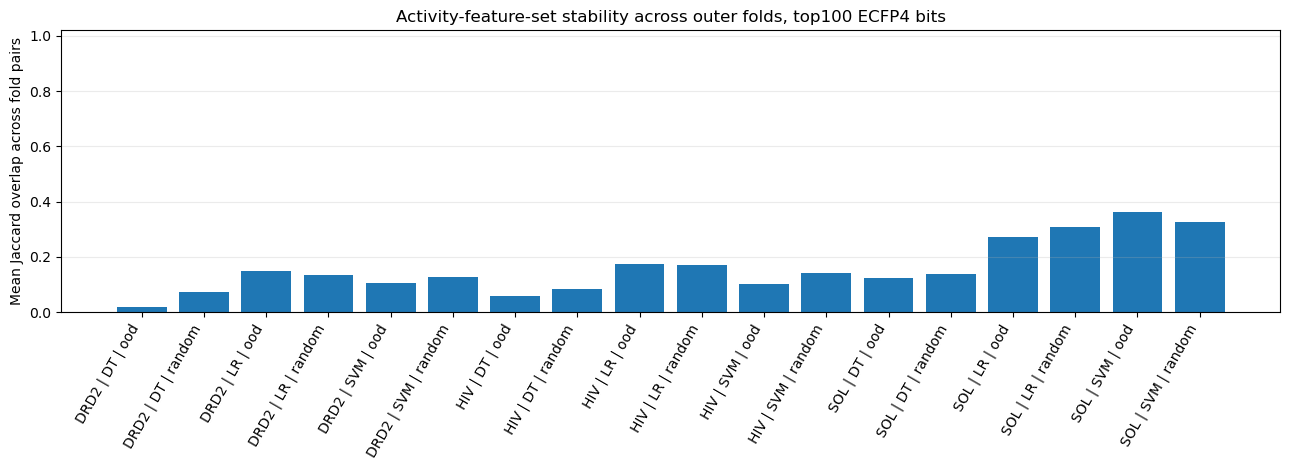

Saved figure: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures/activity_feature_set_jaccard_top100.png


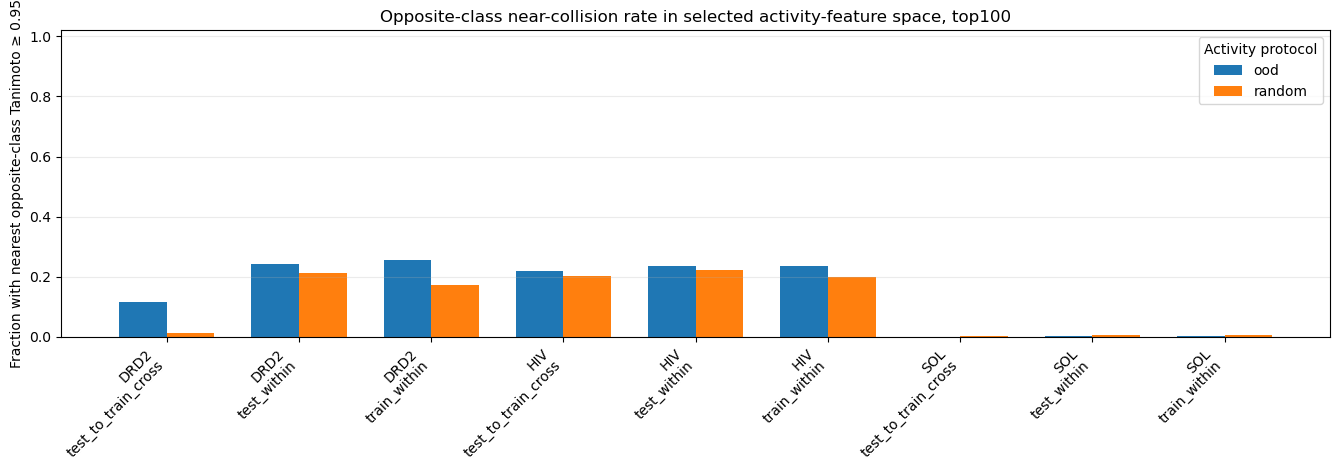

Saved figure: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures/collision_near095_top100_by_context.png

FINAL AUDIT
df_selected_features: shape=(216, 9)
df_feature_overlap_pairwise: shape=(216, 16)
df_feature_overlap_summary: shape=(72, 13)
df_collision: shape=(1944, 25)
df_collision_summary: shape=(216, 18)
Expected collision rows if all combinations present: 1944
Observed collision rows: 1944

OK: collision and feature-overlap analysis completed.


In [3]:
# ============================================================
# Activity-feature-space collision + feature-set overlap analysis
#
# Goal:
#   1. Build the activity-relevant feature sets (List A) used by each
#      activity model across outer folds.
#
#   2. Measure how stable these selected feature sets are across folds:
#        fold 1 vs fold 2
#        fold 1 vs fold 3
#        fold 2 vs fold 3
#
#      Main metric:
#        Jaccard = |A ∩ B| / |A ∪ B|
#
#   3. Restrict ECFP4 fingerprints to these selected activity features and
#      measure whether molecules from opposite activity classes become
#      indistinguishable or nearly indistinguishable.
#
#   Collision contexts:
#      train_within:
#          opposite-class nearest-neighbor similarity inside outer train.
#
#      test_within:
#          opposite-class nearest-neighbor similarity inside outer test.
#
#      test_to_train_cross:
#          for each test molecule, nearest training molecule of the opposite
#          class. This is the most important diagnostic: if a test molecule is
#          identical or nearly identical to an opposite-class training molecule
#          in the selected feature space, the model has strong ambiguity.
#
#   Exact collision:
#      nearest opposite-class Tanimoto = 1.0 in selected-feature space.
#
#   Near collision:
#      nearest opposite-class Tanimoto >= 0.95 or >= 0.90.
#
# Important interpretation:
#   Exact collisions do not prove the fitted model made an error on that exact
#   sample unless predictions are checked, but they show that in the selected
#   feature subspace two opposite-class molecules are indistinguishable.
#   Therefore, no deterministic model using only that restricted representation
#   can assign different representations to them.
#
# Outputs:
#   - cross_dataset_activity_selected_feature_sets.csv
#   - cross_dataset_activity_feature_set_overlap_pairwise.csv
#   - cross_dataset_activity_feature_set_overlap_summary.csv
#   - cross_dataset_activity_feature_space_collision_diagnostics.csv
#   - cross_dataset_activity_feature_space_collision_summary.csv
#   - cross_dataset_activity_feature_space_collision_prof_table_top100.csv
#   - figures/activity_feature_set_jaccard_top100.png
#   - figures/collision_near095_top100_by_context.png
# ============================================================

from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

# ------------------------------------------------------------
# 0. Configuration
# ------------------------------------------------------------

TASK = globals().get("TASK", "hi")
RANDOM_STATE = globals().get("RANDOM_STATE", 42)
N_BITS = int(globals().get("N_BITS", 1024))
RADIUS = int(globals().get("RADIUS", 2))

DATASETS_MAIN = globals().get("DATASETS_MAIN", ["drd2", "hiv", "sol"])
PROJECT_ROOT = Path(globals().get("PROJECT_ROOT", Path.cwd()))

DATA_DIR = PROJECT_ROOT / "data" / TASK
OUT_DIR = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_ROOT.mkdir(parents=True, exist_ok=True)

SUBSET_FILES = {
    "F1": "test_3.csv",
    "F2": "test_2.csv",
    "F3": "test_1.csv",
}

# Final refit / final test mapping.
# fold 1: train F1+F2, test F3
# fold 2: train F1+F3, test F2
# fold 3: train F2+F3, test F1
OUTER_FOLD_TO_TRAIN_TEST = {
    1: (["F1", "F2"], "F3"),
    2: (["F1", "F3"], "F2"),
    3: (["F2", "F3"], "F1"),
}

FOLD_PAIRS_OUTER = [(1, 2), (1, 3), (2, 3)]

MODELS = ["DT", "LR", "SVM"]
PROTOCOLS = ["ood", "random"]

# top50/top100: comparable fixed-size feature sets.
# mass95: smallest feature set explaining 95% cumulative importance.
# positive: all non-zero importance features.
FEATURE_SET_SPECS = [
    {"name": "top50", "kind": "topk", "k": 50},
    {"name": "top100", "kind": "topk", "k": 100},
    {"name": "mass95", "kind": "mass", "mass": 0.95},
    {"name": "positive", "kind": "positive"},
]

SIM_THRESHOLDS = [1.0, 0.95, 0.90]
PAIRWISE_CHUNK_SIZE = 512

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)
print("N_BITS:", N_BITS)

assert N_BITS == 1024, (
    f"This analysis is currently expected to use 1024-bit ECFP4, got N_BITS={N_BITS}. "
    "If you intentionally changed bit size, update List A, List B, and all downstream denominators."
)


# ------------------------------------------------------------
# 1. General utilities
# ------------------------------------------------------------


def detect_smiles_column(df: pd.DataFrame) -> str:
    for col in [
        "smiles",
        "SMILES",
        "canonical_smiles",
        "canonical_smiles_rdkit",
        "mol",
        "molecule",
    ]:
        if col in df.columns:
            return col

    raise ValueError(
        f"No SMILES column found. Available columns: {df.columns.tolist()}"
    )


def detect_binary_label_column(df: pd.DataFrame) -> str:
    candidates = [
        "label",
        "Label",
        "target",
        "Target",
        "y",
        "Y",
        "value",  # Lo-Hi Hi activity label
        "Value",
        "activity",
        "Activity",
        "active",
        "Active",
        "is_active",
        "class",
        "Class",
    ]

    for col in candidates:
        if col not in df.columns:
            continue

        s = df[col].dropna()

        if s.empty:
            continue

        # Boolean case: DRD2/Sol use False/True.
        if pd.api.types.is_bool_dtype(s):
            return col

        # Numeric case: HIV uses 0/1.
        vals_num = pd.to_numeric(s, errors="coerce")

        if vals_num.notna().all():
            unique_vals = np.sort(vals_num.unique())

            if len(unique_vals) == 2:
                return col

        # String categorical case.
        vals_str = set(s.astype(str).str.lower().str.strip().unique())

        allowed = {
            "0",
            "1",
            "0.0",
            "1.0",
            "false",
            "true",
            "inactive",
            "active",
            "negative",
            "positive",
            "neg",
            "pos",
            "-1",
        }

        if vals_str.issubset(allowed) and len(vals_str) <= 2:
            return col

    raise ValueError(
        "Could not infer binary activity label column. "
        f"Available columns: {df.columns.tolist()}"
    )


def binarize_label(s: pd.Series) -> np.ndarray:
    # Boolean case: False -> 0, True -> 1.
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int).to_numpy()

    vals_num = pd.to_numeric(s, errors="coerce")

    if vals_num.notna().all():
        unique_vals = np.sort(vals_num.unique())

        if len(unique_vals) != 2:
            raise ValueError(
                f"Expected binary labels, found {len(unique_vals)} unique values: "
                f"{unique_vals[:20]}"
            )

        # Standard 0/1.
        if set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            return vals_num.astype(int).to_numpy()

        # Standard -1/+1.
        if set(unique_vals).issubset({-1, 1, -1.0, 1.0}):
            return (vals_num > 0).astype(int).to_numpy()

        # Generic two-value numeric encoding:
        # smaller value -> 0, larger value -> 1.
        low, high = unique_vals[0], unique_vals[1]
        return vals_num.map({low: 0, high: 1}).astype(int).to_numpy()

    mapping = {
        "0": 0,
        "0.0": 0,
        "false": 0,
        "inactive": 0,
        "negative": 0,
        "neg": 0,
        "-1": 0,
        "1": 1,
        "1.0": 1,
        "true": 1,
        "active": 1,
        "positive": 1,
        "pos": 1,
    }

    vals = s.astype(str).str.lower().str.strip().map(mapping)

    if vals.isna().any():
        bad = sorted(s[vals.isna()].astype(str).unique())
        raise ValueError(f"Could not binarize labels. Bad values: {bad}")

    return vals.astype(int).to_numpy()


def load_dataset_folds_with_labels(dataset: str) -> dict[str, dict]:
    dataset_dir = DATA_DIR / dataset

    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")

    out = {}

    for fold_name, fname in SUBSET_FILES.items():
        path = dataset_dir / fname

        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path).copy()

        smiles_col = detect_smiles_column(df)
        label_col = detect_binary_label_column(df)

        X, valid_mask = compute_ecfp4_bits(
            df[smiles_col].astype(str).tolist(),
            n_bits=N_BITS,
            radius=RADIUS,
        )

        valid_mask = np.asarray(valid_mask, dtype=bool)

        if not valid_mask.all():
            n_bad = int((~valid_mask).sum())
            print(f"{dataset} | {fold_name}: dropping {n_bad} invalid SMILES")
            df = df.loc[valid_mask].reset_index(drop=True)
            X = X[valid_mask]

        y = binarize_label(df[label_col])

        if len(y) != X.shape[0]:
            raise ValueError(
                f"X/y mismatch for {dataset} {fold_name}: {X.shape[0]} vs {len(y)}"
            )

        out[fold_name] = {
            "df": df.reset_index(drop=True),
            "X": X.astype(np.uint8),
            "y": y.astype(int),
            "smiles_col": smiles_col,
            "label_col": label_col,
        }

        print(
            f"{dataset} | {fold_name} | n={len(y)} | X={X.shape} | "
            f"label_col={label_col} | class_counts={dict(pd.Series(y).value_counts().sort_index())}"
        )

    return out


# ------------------------------------------------------------
# 2. Load and prepare List A
# ------------------------------------------------------------

MODEL_NAME_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "dt": "DT",
    "decision_tree": "DT",
    "lr": "LR",
    "logistic_regression": "LR",
    "svm": "SVM",
    "svm_linear": "SVM",
    "DT": "DT",
    "LR": "LR",
    "SVM": "SVM",
}

FP_NAME_MAP = {
    "ECFP4": "ecfp4",
    "ecfp4": "ecfp4",
    "MACCS": "maccs",
    "maccs": "maccs",
    "RDKit desc": "rdkit_desc",
    "rdkit_desc": "rdkit_desc",
}


def normalize_protocol_name(x) -> str:
    x = str(x).strip().lower()

    if "random" in x:
        return "random"

    if "ood" in x or "holdout" in x:
        return "ood"

    return x


def load_or_get_listA() -> pd.DataFrame:
    if "df_listA" in globals() and isinstance(globals()["df_listA"], pd.DataFrame):
        print("Using df_listA already in memory.")
        return globals()["df_listA"].copy()

    candidate_paths = [
        OUT_DIR / "cross_dataset_listA_activity_feature_importance.csv",
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / TASK
        / "cross_dataset"
        / "cross_dataset_feature_importance_all_tree.csv",
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / TASK
        / "cross_dataset"
        / "cross_dataset_feature_importance_all.csv",
    ]

    for path in candidate_paths:
        if path.exists():
            print("Loading List A from:", path)
            return pd.read_csv(path, low_memory=False).copy()

    raise FileNotFoundError(
        "Could not find List A. Tried:\n" + "\n".join(str(p) for p in candidate_paths)
    )


def prepare_listA(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    original_columns = set(df.columns)

    required = ["dataset", "model", "protocol", "fold", "feature_idx"]

    for col in required:
        if col not in df.columns:
            raise ValueError(f"List A missing required column: {col}")

    if "fingerprint" not in df.columns:
        if "fp_type" in df.columns:
            df["fingerprint"] = df["fp_type"]
        else:
            raise ValueError("List A missing fingerprint/fp_type column.")

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df = df[df["dataset"].isin(DATASETS_MAIN)].copy()

    df["model"] = df["model"].map(MODEL_NAME_MAP).fillna(df["model"].astype(str))
    df["fingerprint"] = (
        df["fingerprint"]
        .map(FP_NAME_MAP)
        .fillna(df["fingerprint"].astype(str).str.lower())
    )

    df = df[df["fingerprint"] == "ecfp4"].copy()

    df["protocol_family"] = df["protocol"].map(normalize_protocol_name)

    df["feature_idx"] = pd.to_numeric(df["feature_idx"], errors="coerce")
    df = df[df["feature_idx"].notna()].copy()
    df["feature_idx"] = df["feature_idx"].astype(int)

    df["fold"] = pd.to_numeric(df["fold"], errors="coerce")
    df = df[df["fold"].notna()].copy()
    df["fold"] = df["fold"].astype(int)

    df["activity_importance"] = 0.0

    dt_mask = df["model"].eq("DT")
    lin_mask = df["model"].isin(["LR", "SVM"])

    if dt_mask.any():
        if "tree_importance" in original_columns:
            source_col = "tree_importance"
        elif "importance_value" in original_columns:
            source_col = "importance_value"
        elif "activity_importance" in original_columns:
            source_col = "activity_importance"
        else:
            raise ValueError(
                "DT rows found but no tree_importance / importance_value column available."
            )

        df.loc[dt_mask, "activity_importance"] = (
            pd.to_numeric(df.loc[dt_mask, source_col], errors="coerce")
            .fillna(0.0)
            .clip(lower=0.0)
            .to_numpy()
        )

    if lin_mask.any():
        source_col = None

        for col in [
            "normalized_abs_importance",
            "abs_weight",
            "abs_importance",
            "importance_value",
            "activity_importance",
        ]:
            if col in original_columns:
                source_col = col
                break

        if source_col is None:
            raise ValueError(
                "LR/SVM rows found but no coefficient/importance column available."
            )

        df.loc[lin_mask, "activity_importance"] = (
            pd.to_numeric(df.loc[lin_mask, source_col], errors="coerce")
            .fillna(0.0)
            .abs()
            .to_numpy()
        )

    max_idx = int(df["feature_idx"].max()) if len(df) else -1

    assert max_idx < N_BITS, (
        f"List A has feature_idx={max_idx}, but N_BITS={N_BITS}. "
        "This means List A is not aligned with the 1024-bit collision analysis."
    )

    df = df[df["feature_idx"].between(0, N_BITS - 1)].copy()

    print("\nPrepared List A")
    print("shape:", df.shape)
    print("datasets:", sorted(df["dataset"].unique()))
    print("models:", sorted(df["model"].unique()))
    print("protocols:", sorted(df["protocol_family"].unique()))
    print("folds:", sorted(df["fold"].unique()))
    print("max feature_idx:", df["feature_idx"].max())

    return df


df_listA_collision = prepare_listA(load_or_get_listA())


# ------------------------------------------------------------
# 3. Select activity feature sets
# ------------------------------------------------------------


def select_activity_bits(
    listA: pd.DataFrame,
    dataset: str,
    model: str,
    protocol: str,
    fold: int,
    spec: dict,
) -> np.ndarray:
    sub = listA[
        (listA["dataset"] == dataset)
        & (listA["model"] == model)
        & (listA["protocol_family"] == protocol)
        & (listA["fold"].astype(int) == int(fold))
        & (listA["fingerprint"] == "ecfp4")
    ].copy()

    if sub.empty:
        return np.array([], dtype=int)

    sub["activity_importance"] = pd.to_numeric(
        sub["activity_importance"],
        errors="coerce",
    ).fillna(0.0)

    sub = sub[sub["activity_importance"] > 0].copy()

    if sub.empty:
        return np.array([], dtype=int)

    agg = (
        sub.groupby("feature_idx", as_index=False)["activity_importance"]
        .mean()
        .sort_values(["activity_importance", "feature_idx"], ascending=[False, True])
        .reset_index(drop=True)
    )

    kind = spec["kind"]

    if kind == "topk":
        k = int(spec["k"])
        selected = agg.head(k)["feature_idx"].to_numpy(dtype=int)

    elif kind == "positive":
        selected = agg["feature_idx"].to_numpy(dtype=int)

    elif kind == "mass":
        threshold = float(spec["mass"])
        total = float(agg["activity_importance"].sum())

        if total <= 0:
            return np.array([], dtype=int)

        agg["cum_mass"] = agg["activity_importance"].cumsum() / total
        selected_idx = np.where(agg["cum_mass"].to_numpy() <= threshold)[0]

        if len(selected_idx) == 0:
            selected = agg.head(1)["feature_idx"].to_numpy(dtype=int)
        else:
            last = min(int(selected_idx[-1]) + 1, len(agg) - 1)
            selected = agg.iloc[: last + 1]["feature_idx"].to_numpy(dtype=int)

    else:
        raise ValueError(f"Unknown feature-set selection kind: {kind}")

    selected = np.asarray(
        sorted(set(int(x) for x in selected if 0 <= int(x) < N_BITS)),
        dtype=int,
    )

    return selected


# ------------------------------------------------------------
# 4. Build selected-feature table and fold-overlap table
# ------------------------------------------------------------

selected_rows = []
overlap_rows = []

for dataset in DATASETS_MAIN:
    for model in MODELS:
        for protocol in PROTOCOLS:
            for spec in FEATURE_SET_SPECS:
                fold_to_bits = {}

                for fold in [1, 2, 3]:
                    bits = select_activity_bits(
                        listA=df_listA_collision,
                        dataset=dataset,
                        model=model,
                        protocol=protocol,
                        fold=fold,
                        spec=spec,
                    )

                    fold_to_bits[fold] = set(bits.tolist())

                    selected_rows.append(
                        {
                            "dataset": dataset,
                            "model": model,
                            "activity_protocol": protocol,
                            "fold": fold,
                            "feature_set_name": spec["name"],
                            "feature_set_kind": spec["kind"],
                            "n_bits_selected": int(len(bits)),
                            "selected_features_json": json.dumps(bits.tolist()),
                            "selected_features_preview": ",".join(map(str, bits[:30])),
                        }
                    )

                for f1, f2 in FOLD_PAIRS_OUTER:
                    a = fold_to_bits[f1]
                    b = fold_to_bits[f2]

                    inter = a & b
                    union = a | b

                    n_a = len(a)
                    n_b = len(b)
                    n_inter = len(inter)
                    n_union = len(union)

                    jaccard = n_inter / n_union if n_union > 0 else np.nan
                    overlap_max_den = (
                        n_inter / max(n_a, n_b) if max(n_a, n_b) > 0 else np.nan
                    )
                    overlap_min_den = (
                        n_inter / min(n_a, n_b) if min(n_a, n_b) > 0 else np.nan
                    )

                    overlap_rows.append(
                        {
                            "dataset": dataset,
                            "model": model,
                            "activity_protocol": protocol,
                            "feature_set_name": spec["name"],
                            "fold_pair": f"{f1}_vs_{f2}",
                            "fold_a": f1,
                            "fold_b": f2,
                            "n_features_total": N_BITS,
                            "n_features_fold_a": n_a,
                            "n_features_fold_b": n_b,
                            "n_intersection": n_inter,
                            "n_union": n_union,
                            "jaccard_overlap": jaccard,
                            "overlap_max_denominator": overlap_max_den,
                            "overlap_min_denominator": overlap_min_den,
                            "intersection_features_json": json.dumps(
                                sorted(list(inter))
                            ),
                        }
                    )

df_selected_features = pd.DataFrame(selected_rows)
df_feature_overlap_pairwise = pd.DataFrame(overlap_rows)

df_feature_overlap_summary = (
    df_feature_overlap_pairwise.groupby(
        ["dataset", "model", "activity_protocol", "feature_set_name"], as_index=False
    )
    .agg(
        mean_n_features=("n_features_fold_a", "mean"),
        mean_jaccard_overlap=("jaccard_overlap", "mean"),
        min_jaccard_overlap=("jaccard_overlap", "min"),
        max_jaccard_overlap=("jaccard_overlap", "max"),
        mean_overlap_max_denominator=("overlap_max_denominator", "mean"),
        min_overlap_max_denominator=("overlap_max_denominator", "min"),
        max_overlap_max_denominator=("overlap_max_denominator", "max"),
        mean_n_intersection=("n_intersection", "mean"),
        mean_n_union=("n_union", "mean"),
    )
    .sort_values(["dataset", "model", "activity_protocol", "feature_set_name"])
    .reset_index(drop=True)
)

selected_path = OUT_DIR / "cross_dataset_activity_selected_feature_sets.csv"
overlap_pairwise_path = (
    OUT_DIR / "cross_dataset_activity_feature_set_overlap_pairwise.csv"
)
overlap_summary_path = (
    OUT_DIR / "cross_dataset_activity_feature_set_overlap_summary.csv"
)

df_selected_features.to_csv(selected_path, index=False)
df_feature_overlap_pairwise.to_csv(overlap_pairwise_path, index=False)
df_feature_overlap_summary.to_csv(overlap_summary_path, index=False)

print("\nSaved selected feature sets:")
print(selected_path)
print("shape:", df_selected_features.shape)

print("\nSaved feature overlap pairwise:")
print(overlap_pairwise_path)
print("shape:", df_feature_overlap_pairwise.shape)

print("\nSaved feature overlap summary:")
print(overlap_summary_path)
print("shape:", df_feature_overlap_summary.shape)

print("\nProfessor table 1: feature-set stability across folds")
display(
    df_feature_overlap_summary[
        df_feature_overlap_summary["feature_set_name"].isin(
            ["top100", "mass95", "positive"]
        )
    ]
    .sort_values(["dataset", "model", "activity_protocol", "feature_set_name"])
    .head(60)
)


# ------------------------------------------------------------
# 5. Tanimoto collision helpers
# ------------------------------------------------------------


def restrict_bits(X: np.ndarray, bits: np.ndarray) -> np.ndarray:
    if len(bits) == 0:
        return np.zeros((X.shape[0], 0), dtype=np.uint8)

    return X[:, bits].astype(np.uint8, copy=False)


def max_tanimoto_to_reference(
    X_query: np.ndarray,
    X_ref: np.ndarray,
    chunk_size: int = PAIRWISE_CHUNK_SIZE,
) -> np.ndarray:
    """
    For each query molecule, compute maximum Tanimoto similarity to a reference set.

    Convention:
      If both restricted fingerprints are all-zero, similarity is set to 1.0,
      because the two molecules are indistinguishable in the selected-feature space.
    """
    if X_query.shape[0] == 0 or X_ref.shape[0] == 0:
        return np.array([], dtype=np.float32)

    Xq = X_query.astype(np.float32, copy=False)
    Xr = X_ref.astype(np.float32, copy=False)

    sq = Xq.sum(axis=1)
    sr = Xr.sum(axis=1)

    out = np.zeros(Xq.shape[0], dtype=np.float32)

    for start in range(0, Xq.shape[0], chunk_size):
        block = Xq[start : start + chunk_size]
        sb = sq[start : start + chunk_size]

        inter = block @ Xr.T
        union = sb[:, None] + sr[None, :] - inter

        sim = np.zeros_like(inter, dtype=np.float32)
        np.divide(inter, union, out=sim, where=union > 0)

        # all-zero vs all-zero: identical representation in this subspace
        sim[union == 0] = 1.0

        out[start : start + chunk_size] = sim.max(axis=1)

    return out


def summarize_similarities(
    sim: np.ndarray,
    X_query_restricted: np.ndarray,
    X_ref_restricted: np.ndarray,
) -> dict:
    if sim.size == 0:
        return {
            "n_query": 0,
            "mean_nearest_opposite_sim": np.nan,
            "median_nearest_opposite_sim": np.nan,
            "q90_nearest_opposite_sim": np.nan,
            "q95_nearest_opposite_sim": np.nan,
            "max_nearest_opposite_sim": np.nan,
            "exact_collision_rate": np.nan,
            "near_collision_rate_095": np.nan,
            "near_collision_rate_090": np.nan,
            "distinguishable_rate_exact": np.nan,
            "distinguishable_rate_095": np.nan,
            "query_zero_vector_rate": np.nan,
            "reference_zero_vector_rate": np.nan,
        }

    exact = float(np.mean(sim >= 1.0 - 1e-12))
    near095 = float(np.mean(sim >= 0.95))
    near090 = float(np.mean(sim >= 0.90))

    query_zero = (
        float(np.mean(X_query_restricted.sum(axis=1) == 0))
        if X_query_restricted.shape[0] > 0
        else np.nan
    )

    ref_zero = (
        float(np.mean(X_ref_restricted.sum(axis=1) == 0))
        if X_ref_restricted.shape[0] > 0
        else np.nan
    )

    return {
        "n_query": int(sim.size),
        "mean_nearest_opposite_sim": float(np.mean(sim)),
        "median_nearest_opposite_sim": float(np.median(sim)),
        "q90_nearest_opposite_sim": float(np.quantile(sim, 0.90)),
        "q95_nearest_opposite_sim": float(np.quantile(sim, 0.95)),
        "max_nearest_opposite_sim": float(np.max(sim)),
        "exact_collision_rate": exact,
        "near_collision_rate_095": near095,
        "near_collision_rate_090": near090,
        "distinguishable_rate_exact": 1.0 - exact,
        "distinguishable_rate_095": 1.0 - near095,
        "query_zero_vector_rate": query_zero,
        "reference_zero_vector_rate": ref_zero,
    }


def compute_collision_rows_for_context(
    dataset: str,
    model: str,
    protocol: str,
    outer_fold: int,
    feature_set_name: str,
    bits: np.ndarray,
    context: str,
    X_query: np.ndarray,
    y_query: np.ndarray,
    X_ref: np.ndarray,
    y_ref: np.ndarray,
) -> list[dict]:
    rows = []

    Xq_restricted_all = restrict_bits(X_query, bits)
    Xr_restricted_all = restrict_bits(X_ref, bits)

    pooled_sims = []
    pooled_Xq = []
    pooled_Xr = []

    for cls in [0, 1]:
        opp = 1 - cls

        q_mask = y_query == cls
        r_mask = y_ref == opp

        Xq = Xq_restricted_all[q_mask]
        Xr = Xr_restricted_all[r_mask]

        sim = max_tanimoto_to_reference(Xq, Xr)

        if sim.size > 0:
            pooled_sims.append(sim)
            pooled_Xq.append(Xq)
            pooled_Xr.append(Xr)

        row = {
            "dataset": dataset,
            "model": model,
            "activity_protocol": protocol,
            "outer_fold": int(outer_fold),
            "feature_set_name": feature_set_name,
            "n_bits_selected": int(len(bits)),
            "context": context,
            "class_direction": f"{cls}_to_{opp}",
            "query_class": int(cls),
            "reference_class": int(opp),
            "n_query_class": int(q_mask.sum()),
            "n_reference_opposite_class": int(r_mask.sum()),
        }

        row.update(summarize_similarities(sim, Xq, Xr))
        rows.append(row)

    if pooled_sims:
        sim_pooled = np.concatenate(pooled_sims)
        Xq_pooled = np.vstack(pooled_Xq)
        Xr_pooled = np.vstack(pooled_Xr)
    else:
        sim_pooled = np.array([], dtype=np.float32)
        Xq_pooled = np.zeros((0, len(bits)), dtype=np.uint8)
        Xr_pooled = np.zeros((0, len(bits)), dtype=np.uint8)

    pooled_row = {
        "dataset": dataset,
        "model": model,
        "activity_protocol": protocol,
        "outer_fold": int(outer_fold),
        "feature_set_name": feature_set_name,
        "n_bits_selected": int(len(bits)),
        "context": context,
        "class_direction": "pooled",
        "query_class": np.nan,
        "reference_class": np.nan,
        "n_query_class": int(len(y_query)),
        "n_reference_opposite_class": int(len(y_ref)),
    }

    pooled_row.update(summarize_similarities(sim_pooled, Xq_pooled, Xr_pooled))
    rows.append(pooled_row)

    return rows


# ------------------------------------------------------------
# 6. Main collision analysis
# ------------------------------------------------------------

collision_rows = []
t0_collision = time.time()

for dataset in DATASETS_MAIN:
    print("\n" + "=" * 100)
    print(f"Collision analysis: {dataset.upper()}")
    print("=" * 100)

    folds = load_dataset_folds_with_labels(dataset)

    for model in MODELS:
        for protocol in PROTOCOLS:
            for outer_fold, (
                train_folds,
                test_fold,
            ) in OUTER_FOLD_TO_TRAIN_TEST.items():
                X_train = np.vstack([folds[f]["X"] for f in train_folds])
                y_train = np.concatenate([folds[f]["y"] for f in train_folds]).astype(
                    int
                )

                X_test = folds[test_fold]["X"]
                y_test = folds[test_fold]["y"].astype(int)

                for spec in FEATURE_SET_SPECS:
                    bits = select_activity_bits(
                        listA=df_listA_collision,
                        dataset=dataset,
                        model=model,
                        protocol=protocol,
                        fold=outer_fold,
                        spec=spec,
                    )

                    if len(bits) == 0:
                        print(
                            f"WARNING: no selected bits for "
                            f"{dataset}|{model}|{protocol}|fold={outer_fold}|{spec['name']}"
                        )
                        continue

                    print(
                        f"{dataset} | {model} | {protocol} | fold={outer_fold} | "
                        f"{spec['name']} | bits={len(bits)}"
                    )

                    collision_rows.extend(
                        compute_collision_rows_for_context(
                            dataset=dataset,
                            model=model,
                            protocol=protocol,
                            outer_fold=outer_fold,
                            feature_set_name=spec["name"],
                            bits=bits,
                            context="train_within",
                            X_query=X_train,
                            y_query=y_train,
                            X_ref=X_train,
                            y_ref=y_train,
                        )
                    )

                    collision_rows.extend(
                        compute_collision_rows_for_context(
                            dataset=dataset,
                            model=model,
                            protocol=protocol,
                            outer_fold=outer_fold,
                            feature_set_name=spec["name"],
                            bits=bits,
                            context="test_within",
                            X_query=X_test,
                            y_query=y_test,
                            X_ref=X_test,
                            y_ref=y_test,
                        )
                    )

                    collision_rows.extend(
                        compute_collision_rows_for_context(
                            dataset=dataset,
                            model=model,
                            protocol=protocol,
                            outer_fold=outer_fold,
                            feature_set_name=spec["name"],
                            bits=bits,
                            context="test_to_train_cross",
                            X_query=X_test,
                            y_query=y_test,
                            X_ref=X_train,
                            y_ref=y_train,
                        )
                    )

df_collision = pd.DataFrame(collision_rows)

if df_collision.empty:
    raise RuntimeError("Collision analysis produced no rows.")

diagnostics_path = (
    OUT_DIR / "cross_dataset_activity_feature_space_collision_diagnostics.csv"
)
df_collision.to_csv(diagnostics_path, index=False)

print("\nSaved collision diagnostics:")
print(diagnostics_path)
print("shape:", df_collision.shape)
print(f"Collision analysis time: {(time.time() - t0_collision) / 60:.1f} min")


# ------------------------------------------------------------
# 7. Collision summary and professor table
# ------------------------------------------------------------

df_collision_summary = (
    df_collision[df_collision["class_direction"] == "pooled"]
    .groupby(
        [
            "dataset",
            "model",
            "activity_protocol",
            "feature_set_name",
            "context",
        ],
        as_index=False,
    )
    .agg(
        n_outer_folds=("outer_fold", "nunique"),
        mean_n_bits_selected=("n_bits_selected", "mean"),
        mean_nearest_opposite_sim=("mean_nearest_opposite_sim", "mean"),
        median_nearest_opposite_sim=("median_nearest_opposite_sim", "mean"),
        q90_nearest_opposite_sim=("q90_nearest_opposite_sim", "mean"),
        q95_nearest_opposite_sim=("q95_nearest_opposite_sim", "mean"),
        exact_collision_rate=("exact_collision_rate", "mean"),
        near_collision_rate_095=("near_collision_rate_095", "mean"),
        near_collision_rate_090=("near_collision_rate_090", "mean"),
        distinguishable_rate_exact=("distinguishable_rate_exact", "mean"),
        distinguishable_rate_095=("distinguishable_rate_095", "mean"),
        query_zero_vector_rate=("query_zero_vector_rate", "mean"),
        reference_zero_vector_rate=("reference_zero_vector_rate", "mean"),
    )
    .sort_values(
        ["dataset", "model", "activity_protocol", "feature_set_name", "context"]
    )
    .reset_index(drop=True)
)

summary_path = OUT_DIR / "cross_dataset_activity_feature_space_collision_summary.csv"
df_collision_summary.to_csv(summary_path, index=False)

print("\nSaved collision summary:")
print(summary_path)
print("shape:", df_collision_summary.shape)

# Professor-facing compact table: top100, pooled, averaged over folds.
prof_table_top100 = df_collision_summary[
    df_collision_summary["feature_set_name"] == "top100"
].copy()

prof_table_top100["exact_collision_pct"] = (
    100.0 * prof_table_top100["exact_collision_rate"]
)
prof_table_top100["near_collision_095_pct"] = (
    100.0 * prof_table_top100["near_collision_rate_095"]
)
prof_table_top100["distinguishable_095_pct"] = (
    100.0 * prof_table_top100["distinguishable_rate_095"]
)

prof_table_top100 = prof_table_top100[
    [
        "dataset",
        "model",
        "activity_protocol",
        "context",
        "mean_n_bits_selected",
        "mean_nearest_opposite_sim",
        "q95_nearest_opposite_sim",
        "exact_collision_pct",
        "near_collision_095_pct",
        "distinguishable_095_pct",
        "query_zero_vector_rate",
    ]
].sort_values(["dataset", "model", "activity_protocol", "context"])

prof_table_path = (
    OUT_DIR / "cross_dataset_activity_feature_space_collision_prof_table_top100.csv"
)
prof_table_top100.to_csv(prof_table_path, index=False)

print("\nProfessor table 2: collision/indistinguishability, top100 activity features")
print(prof_table_path)
display(prof_table_top100.head(80))


# ------------------------------------------------------------
# 8. Plots
# ------------------------------------------------------------

# Plot A: feature-set stability across folds, top100.
plot_overlap = df_feature_overlap_summary[
    df_feature_overlap_summary["feature_set_name"] == "top100"
].copy()

if not plot_overlap.empty:
    plot_overlap["label"] = (
        plot_overlap["dataset"].str.upper()
        + " | "
        + plot_overlap["model"]
        + " | "
        + plot_overlap["activity_protocol"]
    )

    plot_overlap = plot_overlap.sort_values(["dataset", "model", "activity_protocol"])

    fig, ax = plt.subplots(figsize=(13, 4.8))
    x = np.arange(len(plot_overlap))

    ax.bar(x, plot_overlap["mean_jaccard_overlap"].to_numpy())
    ax.set_title("Activity-feature-set stability across outer folds, top100 ECFP4 bits")
    ax.set_ylabel("Mean Jaccard overlap across fold pairs")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_overlap["label"], rotation=60, ha="right")
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()

    out_fig = FIG_ROOT / "activity_feature_set_jaccard_top100.png"
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", out_fig)


# Plot B: near-collision rate by context, top100, aggregated across models and folds.
plot_collision = (
    df_collision[
        (df_collision["class_direction"] == "pooled")
        & (df_collision["feature_set_name"] == "top100")
    ]
    .groupby(["dataset", "activity_protocol", "context"], as_index=False)
    .agg(
        near_collision_rate_095=("near_collision_rate_095", "mean"),
        mean_nearest_opposite_sim=("mean_nearest_opposite_sim", "mean"),
        exact_collision_rate=("exact_collision_rate", "mean"),
    )
)

context_order = ["train_within", "test_within", "test_to_train_cross"]

if not plot_collision.empty:
    plot_collision["context_order"] = plot_collision["context"].map(
        {c: i for i, c in enumerate(context_order)}
    )

    plot_collision = plot_collision.sort_values(
        ["dataset", "context_order", "activity_protocol"]
    )

    labels_df = (
        plot_collision[["dataset", "context"]]
        .drop_duplicates()
        .sort_values(["dataset", "context"])
        .reset_index(drop=True)
    )

    labels = [
        f"{row.dataset.upper()}\n{row.context}"
        for row in labels_df.itertuples(index=False)
    ]

    x = np.arange(len(labels))
    width = 0.36

    fig, ax = plt.subplots(figsize=(13.5, 4.8))

    for protocol, offset in [("ood", -width / 2), ("random", width / 2)]:
        vals = []

        for row in labels_df.itertuples(index=False):
            sub = plot_collision[
                (plot_collision["dataset"] == row.dataset)
                & (plot_collision["context"] == row.context)
                & (plot_collision["activity_protocol"] == protocol)
            ]

            vals.append(
                float(sub["near_collision_rate_095"].iloc[0]) if len(sub) else np.nan
            )

        ax.bar(x + offset, vals, width=width, label=protocol)

    ax.set_title(
        "Opposite-class near-collision rate in selected activity-feature space, top100"
    )
    ax.set_ylabel("Fraction with nearest opposite-class Tanimoto ≥ 0.95")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.02)
    ax.legend(title="Activity protocol")
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()

    out_fig = FIG_ROOT / "collision_near095_top100_by_context.png"
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", out_fig)


# ------------------------------------------------------------
# 9. Final audit
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL AUDIT")
print("=" * 100)

for name, df in [
    ("df_selected_features", df_selected_features),
    ("df_feature_overlap_pairwise", df_feature_overlap_pairwise),
    ("df_feature_overlap_summary", df_feature_overlap_summary),
    ("df_collision", df_collision),
    ("df_collision_summary", df_collision_summary),
]:
    print(f"{name}: shape={df.shape}")

max_listA_idx = int(
    pd.to_numeric(df_listA_collision["feature_idx"], errors="coerce").max()
)
assert (
    max_listA_idx < N_BITS
), f"List A max feature_idx={max_listA_idx}, N_BITS={N_BITS}"

max_selected_idx = -1
if len(df_selected_features):
    all_features = []

    for x in df_selected_features["selected_features_json"].dropna():
        all_features.extend(json.loads(x))

    if all_features:
        max_selected_idx = max(all_features)

assert (
    max_selected_idx < N_BITS
), f"Selected features max_idx={max_selected_idx}, expected < {N_BITS}"

assert df_feature_overlap_pairwise["jaccard_overlap"].dropna().between(0, 1).all()
assert df_collision["exact_collision_rate"].dropna().between(0, 1).all()
assert df_collision["near_collision_rate_095"].dropna().between(0, 1).all()
assert df_collision["mean_nearest_opposite_sim"].dropna().between(0, 1).all()

expected_collision_rows = (
    len(DATASETS_MAIN)
    * len(MODELS)
    * len(PROTOCOLS)
    * 3
    * len(FEATURE_SET_SPECS)
    * 3
    * 3
)

print("Expected collision rows if all combinations present:", expected_collision_rows)
print("Observed collision rows:", len(df_collision))

print("\nOK: collision and feature-overlap analysis completed.")

In [6]:
# ============================================================
# 12. PAPER TABLES — main (compact) + appendix (full diagnostics)
#
# Both tables: top100 selected activity features, pooled class direction,
#              averaged over the three outer folds.
#
# TABLE 1 (main):     compact, 6 columns, OOD (random) per cell.
# TABLE 2 (appendix): full diagnostics for reviewers, one row per
#                     (dataset, model, protocol, context).
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

FEATURE_SET_FOR_TABLE = "top100"
MODEL_ORDER = ["DT", "LR", "SVM"]
DATASET_ORDER = [d for d in DATASETS_MAIN]
DATASET_LABELS_SHORT = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}
CONTEXT_ORDER = ["train_within", "test_within", "test_to_train_cross"]
CONTEXT_LABELS = {
    "train_within": "Train",
    "test_within": "Test",
    "test_to_train_cross": "Test->Train",
}


# ------------------------------------------------------------
# Source slices
# ------------------------------------------------------------

coll = df_collision_summary[
    df_collision_summary["feature_set_name"] == FEATURE_SET_FOR_TABLE
].copy()

jacS = df_feature_overlap_summary[
    df_feature_overlap_summary["feature_set_name"] == FEATURE_SET_FOR_TABLE
].copy()

assert (
    not coll.empty
), f"No collision-summary rows found for feature_set_name={FEATURE_SET_FOR_TABLE}."

assert (
    not jacS.empty
), f"No feature-overlap rows found for feature_set_name={FEATURE_SET_FOR_TABLE}."


def get_coll(dataset, model, protocol, context, col):
    sub = coll[
        (coll["dataset"] == dataset)
        & (coll["model"] == model)
        & (coll["activity_protocol"] == protocol)
        & (coll["context"] == context)
    ]

    return float(sub[col].iloc[0]) if (not sub.empty and col in sub.columns) else np.nan


def get_jac(dataset, model, protocol):
    sub = jacS[
        (jacS["dataset"] == dataset)
        & (jacS["model"] == model)
        & (jacS["activity_protocol"] == protocol)
    ]

    return float(sub["mean_jaccard_overlap"].iloc[0]) if not sub.empty else np.nan


def fmt_pair(v_ood, v_rand, pct=False):
    def f(x):
        if pd.isna(x):
            return "--"

        return f"{x:.1f}" if pct else f"{x:.2f}"

    return f"{f(v_ood)} ({f(v_rand)})"


def latex_escape(x):
    if pd.isna(x):
        return "--"

    s = str(x)

    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }

    for old, new in replacements.items():
        s = s.replace(old, new)

    return s


# ============================================================
# TABLE 1 — MAIN COMPACT
# ============================================================

main_rows = []

for dataset in DATASET_ORDER:
    for model in MODEL_ORDER:
        row = {
            "Dataset": DATASET_LABELS_SHORT.get(dataset, dataset.upper()),
            "Model": model,
            "Jaccard": fmt_pair(
                get_jac(dataset, model, "ood"),
                get_jac(dataset, model, "random"),
            ),
            "Tcross": fmt_pair(
                get_coll(
                    dataset,
                    model,
                    "ood",
                    "test_to_train_cross",
                    "mean_nearest_opposite_sim",
                ),
                get_coll(
                    dataset,
                    model,
                    "random",
                    "test_to_train_cross",
                    "mean_nearest_opposite_sim",
                ),
            ),
            "ExactTest": fmt_pair(
                100.0
                * get_coll(
                    dataset,
                    model,
                    "ood",
                    "test_within",
                    "exact_collision_rate",
                ),
                100.0
                * get_coll(
                    dataset,
                    model,
                    "random",
                    "test_within",
                    "exact_collision_rate",
                ),
                pct=True,
            ),
            "ExactCross": fmt_pair(
                100.0
                * get_coll(
                    dataset,
                    model,
                    "ood",
                    "test_to_train_cross",
                    "exact_collision_rate",
                ),
                100.0
                * get_coll(
                    dataset,
                    model,
                    "random",
                    "test_to_train_cross",
                    "exact_collision_rate",
                ),
                pct=True,
            ),
        }

        main_rows.append(row)

df_main = pd.DataFrame(main_rows)

print("=" * 80)
print("TABLE 1 — MAIN (compact). Format: OOD (random).")
print("=" * 80)
display(df_main)

main_csv_path = OUT_DIR / "paper_table_main_compact.csv"
df_main.to_csv(main_csv_path, index=False)

print("Saved:", main_csv_path)


# ============================================================
# TABLE 2 — APPENDIX FULL DIAGNOSTICS
# One row per (dataset, model, protocol, context).
# Reviewer-facing: all relevant numbers in one place.
# ============================================================

appendix_rows = []

for dataset in DATASET_ORDER:
    for model in MODEL_ORDER:
        jac_ood = get_jac(dataset, model, "ood")
        jac_rnd = get_jac(dataset, model, "random")

        for protocol in ["ood", "random"]:
            jac_val = jac_ood if protocol == "ood" else jac_rnd

            for context in CONTEXT_ORDER:
                appendix_rows.append(
                    {
                        "Dataset": DATASET_LABELS_SHORT.get(
                            dataset,
                            dataset.upper(),
                        ),
                        "Model": model,
                        "Protocol": "OOD" if protocol == "ood" else "Random",
                        "Context": CONTEXT_LABELS[context],
                        "|S|": get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "mean_n_bits_selected",
                        ),
                        "Jaccard": jac_val,
                        "MeanSim": get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "mean_nearest_opposite_sim",
                        ),
                        "q95Sim": get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "q95_nearest_opposite_sim",
                        ),
                        "Exact(%)": 100.0
                        * get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "exact_collision_rate",
                        ),
                        "Near095(%)": 100.0
                        * get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "near_collision_rate_095",
                        ),
                        "Near090(%)": 100.0
                        * get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "near_collision_rate_090",
                        ),
                        "ZeroVec(%)": 100.0
                        * get_coll(
                            dataset,
                            model,
                            protocol,
                            context,
                            "query_zero_vector_rate",
                        ),
                    }
                )

df_appendix = pd.DataFrame(appendix_rows)

# Round numeric columns for readability.
num_round = {
    "|S|": 1,
    "Jaccard": 3,
    "MeanSim": 3,
    "q95Sim": 3,
    "Exact(%)": 1,
    "Near095(%)": 1,
    "Near090(%)": 1,
    "ZeroVec(%)": 1,
}

for c, d in num_round.items():
    if c in df_appendix.columns:
        df_appendix[c] = df_appendix[c].round(d)

print("\n" + "=" * 80)
print("TABLE 2 — APPENDIX (full diagnostics, per context).")
print("=" * 80)
display(df_appendix)

appendix_csv_path = OUT_DIR / "paper_table_appendix_full.csv"
df_appendix.to_csv(appendix_csv_path, index=False)

print("Saved:", appendix_csv_path)


# ============================================================
# LaTeX export — MAIN (booktabs, LNCS-compliant)
# ============================================================

main_header = (
    "Dataset & Model & Jaccard & $T_{\\mathrm{cross}}$ "
    "& Exact Test & Exact Cross \\\\"
)

main_body = []
prev = None

for _, r in df_main.iterrows():
    if prev is not None and r["Dataset"] != prev:
        main_body.append("\\addlinespace")

    main_body.append(
        f"{latex_escape(r['Dataset'])} & "
        f"{latex_escape(r['Model'])} & "
        f"{latex_escape(r['Jaccard'])} & "
        f"{latex_escape(r['Tcross'])} & "
        f"{latex_escape(r['ExactTest'])} & "
        f"{latex_escape(r['ExactCross'])} \\\\"
    )

    prev = r["Dataset"]

main_caption = (
    "Rule stability and opposite-class indistinguishability in the selected "
    "activity-feature space (top-100 ECFP4 bits), averaged over the three "
    "outer folds. \\textit{Jaccard} is the mean pairwise overlap of the "
    "selected features across folds (lower values indicate a less stable "
    "learned rule). $T_{\\mathrm{cross}}$ is the mean nearest opposite-class "
    "Tanimoto similarity from test to training molecules in the restricted "
    "space. \\textit{Exact Test} and \\textit{Exact Cross} report the "
    "percentage of molecules whose nearest opposite-class neighbour is "
    "identical ($T{=}1$) within the test fold and from test to training, "
    "respectively. Each cell reports the OOD-holdout value with the "
    "random-shuffle value in parentheses. Full per-context diagnostics, "
    "including near-collision rates and the fraction of molecules outside "
    "the model's feature support, are reported in "
    "Table~\\ref{tab:appendix_full}."
)

main_tex = (
    "\\begin{table}[t]\n"
    "\\centering\n"
    "\\small\n"
    f"\\caption{{{main_caption}}}\n"
    "\\label{tab:concept_shift_main}\n"
    "\\begin{tabular}{llcccc}\n"
    "\\toprule\n"
    f"{main_header}\n"
    "\\midrule\n" + "\n".join(main_body) + "\n\\bottomrule\n"
    "\\end{tabular}\n"
    "\\end{table}\n"
)

main_tex_path = OUT_DIR / "paper_table_main_compact.tex"

with open(main_tex_path, "w", encoding="utf-8") as f:
    f.write(main_tex)

print("\nSaved LaTeX main table:")
print(main_tex_path)

print("\nLaTeX main table preview:")
print(main_tex)


# ============================================================
# LaTeX export — APPENDIX FULL DIAGNOSTICS
# ============================================================

appendix_header = (
    "Dataset & Model & Protocol & Context & $|S|$ & Jaccard & MeanSim "
    "& q95Sim & Exact & Near095 & Near090 & ZeroVec \\\\"
)

appendix_body = []
prev_key = None

for _, r in df_appendix.iterrows():
    key = (r["Dataset"], r["Model"])

    if prev_key is not None and key != prev_key:
        appendix_body.append("\\addlinespace")

    appendix_body.append(
        f"{latex_escape(r['Dataset'])} & "
        f"{latex_escape(r['Model'])} & "
        f"{latex_escape(r['Protocol'])} & "
        f"{latex_escape(r['Context'])} & "
        f"{r['|S|']:.1f} & "
        f"{r['Jaccard']:.3f} & "
        f"{r['MeanSim']:.3f} & "
        f"{r['q95Sim']:.3f} & "
        f"{r['Exact(%)']:.1f} & "
        f"{r['Near095(%)']:.1f} & "
        f"{r['Near090(%)']:.1f} & "
        f"{r['ZeroVec(%)']:.1f} \\\\"
    )

    prev_key = key

appendix_caption = (
    "Full diagnostics for rule stability and opposite-class "
    "indistinguishability in the selected activity-feature space "
    "(top-100 ECFP4 bits). Rows are reported separately for protocol and "
    "collision context. $|S|$ is the mean number of selected activity "
    "features. MeanSim and q95Sim are the mean and 95th percentile of the "
    "nearest opposite-class Tanimoto similarity. Exact, Near095 and Near090 "
    "are percentages of molecules whose nearest opposite-class neighbour has "
    "$T{=}1$, $T{\\geq}0.95$ and $T{\\geq}0.90$, respectively. ZeroVec "
    "reports the percentage of query molecules with no active bit in the "
    "selected feature subspace."
)

appendix_tex = (
    "\\begin{table}[t]\n"
    "\\centering\n"
    "\\scriptsize\n"
    f"\\caption{{{appendix_caption}}}\n"
    "\\label{tab:appendix_full}\n"
    "\\begin{tabular}{llllrrrrrrrr}\n"
    "\\toprule\n"
    f"{appendix_header}\n"
    "\\midrule\n" + "\n".join(appendix_body) + "\n\\bottomrule\n"
    "\\end{tabular}\n"
    "\\end{table}\n"
)

appendix_tex_path = OUT_DIR / "paper_table_appendix_full.tex"

with open(appendix_tex_path, "w", encoding="utf-8") as f:
    f.write(appendix_tex)

print("\nSaved LaTeX appendix table:")
print(appendix_tex_path)


# ============================================================
# Final audit
# ============================================================

print("\n" + "=" * 80)
print("FINAL AUDIT — PAPER TABLES")
print("=" * 80)

print("df_main shape:", df_main.shape)
print("df_appendix shape:", df_appendix.shape)

expected_main_rows = len(DATASET_ORDER) * len(MODEL_ORDER)
expected_appendix_rows = len(DATASET_ORDER) * len(MODEL_ORDER) * 2 * len(CONTEXT_ORDER)

assert (
    df_main.shape[0] == expected_main_rows
), f"df_main has {df_main.shape[0]} rows, expected {expected_main_rows}"

assert (
    df_appendix.shape[0] == expected_appendix_rows
), f"df_appendix has {df_appendix.shape[0]} rows, expected {expected_appendix_rows}"

assert not df_main.isna().any().any(), "df_main contains NaN values."

numeric_cols_appendix = [
    "|S|",
    "Jaccard",
    "MeanSim",
    "q95Sim",
    "Exact(%)",
    "Near095(%)",
    "Near090(%)",
    "ZeroVec(%)",
]

for c in numeric_cols_appendix:
    assert c in df_appendix.columns, f"Missing appendix column: {c}"

    vals = pd.to_numeric(df_appendix[c], errors="coerce")

    assert vals.notna().all(), f"Column {c} contains non-numeric/NaN values."

for c in ["Jaccard", "MeanSim", "q95Sim"]:
    assert df_appendix[c].between(0, 1).all(), f"{c} outside [0,1]"

for c in ["Exact(%)", "Near095(%)", "Near090(%)", "ZeroVec(%)"]:
    assert df_appendix[c].between(0, 100).all(), f"{c} outside [0,100]"

for p in [
    main_csv_path,
    appendix_csv_path,
    main_tex_path,
    appendix_tex_path,
]:
    assert p.exists(), f"Missing saved output: {p}"
    assert p.stat().st_size > 0, f"Saved output is empty: {p}"

print("\nSaved outputs:")
print("CSV main:     ", main_csv_path)
print("CSV appendix: ", appendix_csv_path)
print("TeX main:     ", main_tex_path)
print("TeX appendix: ", appendix_tex_path)

print("\nOK: paper tables exported successfully.")

TABLE 1 — MAIN (compact). Format: OOD (random).


,Dataset,Model,Jaccard,Tcross,ExactTest,ExactCross
0,DRD2,DT,0.02 (0.07),0.74 (0.59),40.7 (19.9),32.8 (1.2)
1,DRD2,LR,0.15 (0.13),0.56 (0.53),16.1 (20.2),0.7 (0.6)
2,DRD2,SVM,0.11 (0.13),0.58 (0.54),16.1 (23.8),1.4 (2.0)
3,HIV,DT,0.06 (0.08),0.67 (0.70),29.3 (32.9),28.3 (32.2)
4,HIV,LR,0.17 (0.17),0.52 (0.52),18.0 (16.1),13.6 (12.1)
5,HIV,SVM,0.10 (0.14),0.58 (0.57),23.2 (17.5),23.5 (16.8)
6,Sol,DT,0.12 (0.14),0.59 (0.63),0.7 (1.5),0.1 (1.4)
7,Sol,LR,0.27 (0.31),0.46 (0.46),0.3 (0.5),0.0 (0.0)
8,Sol,SVM,0.36 (0.33),0.49 (0.49),0.0 (0.0),0.0 (0.0)


Saved: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/paper_table_main_compact.csv

TABLE 2 — APPENDIX (full diagnostics, per context).


,Dataset,Model,Protocol,Context,|S|,Jaccard,MeanSim,q95Sim,Exact(%),Near095(%),Near090(%),ZeroVec(%)
0,DRD2,DT,OOD,Train,45.0,0.020,0.843,1.000,45.7,45.7,50.1,1.4
1,DRD2,DT,OOD,Test,45.0,0.020,0.830,1.000,40.7,40.7,44.9,1.2
2,DRD2,DT,OOD,Test->Train,45.0,0.020,0.744,0.848,32.8,32.8,32.9,1.2
3,DRD2,DT,Random,Train,76.0,0.074,0.750,1.000,13.5,13.6,22.6,0.0
4,DRD2,DT,Random,Test,76.0,0.074,0.753,1.000,19.9,20.0,26.2,0.0
5,DRD2,DT,Random,Test->Train,76.0,0.074,0.589,0.775,1.2,1.2,1.2,0.0
6,DRD2,LR,OOD,Train,78.0,0.149,0.745,1.000,15.4,15.7,25.1,0.0
7,DRD2,LR,OOD,Test,78.0,0.149,0.749,1.000,16.1,16.1,23.4,0.0
8,DRD2,LR,OOD,Test->Train,78.0,0.149,0.563,0.720,0.7,0.7,1.0,0.0
9,DRD2,LR,Random,Train,100.0,0.134,0.735,1.000,18.0,18.0,24.8,0.0


Saved: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/paper_table_appendix_full.csv

Saved LaTeX main table:
/Users/francescocapria/Desktop/drug-discovery-lohi/results/results_classifier_shift_test/hi/paper_table_main_compact.tex

LaTeX main table preview:
\begin{table}[t]
\centering
\small
\caption{Rule stability and opposite-class indistinguishability in the selected activity-feature space (top-100 ECFP4 bits), averaged over the three outer folds. \textit{Jaccard} is the mean pairwise overlap of the selected features across folds (lower values indicate a less stable learned rule). $T_{\mathrm{cross}}$ is the mean nearest opposite-class Tanimoto similarity from test to training molecules in the restricted space. \textit{Exact Test} and \textit{Exact Cross} report the percentage of molecules whose nearest opposite-class neighbour is identical ($T{=}1$) within the test fold and from test to training, respectively. Each cell reports the OOD-ho